# YOLO Inference Notebook
Run these cells in order every time you start a new Colab session.

**What this notebook does:**
- Mounts Drive
- Downloads CBIS-DDSM dataset
- Loads the trained model from Drive
- Runs inference and saves JSON output

**No training required** — uses saved best.pt from Drive.

## Step 1: Mount Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')
print('Drive mounted!')

Mounted at /content/drive
Drive mounted!


## Step 2: Install dependencies

In [2]:
!pip install ultralytics kagglehub -q
print('Done!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 24.1 MB/s eta 0:00:00
Done!


## Step 3: Download CBIS-DDSM dataset
This downloads to `/root/.cache/` — disappears when session ends, must re-run each time.

In [3]:
import kagglehub
import os

path = kagglehub.dataset_download('awsaf49/cbis-ddsm-breast-cancer-image-dataset')
print(f'Dataset downloaded to: {path}')

KAGGLE_BASE = path
JPEG_BASE   = os.path.join(KAGGLE_BASE, 'jpeg')
CSV_BASE    = os.path.join(KAGGLE_BASE, 'csv')

# Quick check
print(f'jpeg folder exists: {os.path.exists(JPEG_BASE)}')
print(f'csv folder exists:  {os.path.exists(CSV_BASE)}')

Using Colab cache for faster access to the 'cbis-ddsm-breast-cancer-image-dataset' dataset.
Dataset downloaded to: /kaggle/input/cbis-ddsm-breast-cancer-image-dataset
jpeg folder exists: True
csv folder exists:  True


## Step 4: Load CSVs and fix paths

In [4]:
import pandas as pd

mass_train = pd.read_csv(os.path.join(CSV_BASE, 'mass_case_description_train_set.csv'))
mass_test  = pd.read_csv(os.path.join(CSV_BASE, 'mass_case_description_test_set.csv'))
df_all = pd.concat([mass_train, mass_test], ignore_index=True)
print(f'Total records: {len(df_all)}')

def get_local_path(path_str):
    """Parse CBIS-DDSM path format -> local jpeg path"""
    if pd.isna(path_str):
        return None
    parts = path_str.strip().split('/')
    if len(parts) < 3:
        return None
    uid2   = parts[2]
    folder = os.path.join(JPEG_BASE, uid2)
    if not os.path.exists(folder):
        return None
    jpgs = [f for f in os.listdir(folder) if f.endswith('.jpg')]
    if not jpgs:
        return None
    return os.path.join(folder, jpgs[0])

df_all['img_local']  = df_all['image file path'].apply(get_local_path)
df_all['mask_local'] = df_all['ROI mask file path'].apply(get_local_path)

img_found  = df_all['img_local'].notna().sum()
mask_found = df_all['mask_local'].notna().sum()
both_found = (df_all['img_local'].notna() & df_all['mask_local'].notna()).sum()

print(f'Images found:         {img_found}')
print(f'Masks found:          {mask_found}')
print(f'Both img+mask found:  {both_found}')

Total records: 1696
Images found:         1696
Masks found:          1696
Both img+mask found:  1696


## Step 5: Build YOLO dataset folder structure
Needed so the model knows where to find images. Must re-run each session.

In [5]:
import cv2
import shutil
import random
from collections import defaultdict

YOLO_DIR = '/content/yolo_dataset'
IMG_SIZE = 640
BATCH    = 16

for split in ['train', 'val']:
    os.makedirs(f'{YOLO_DIR}/images/{split}', exist_ok=True)
    os.makedirs(f'{YOLO_DIR}/labels/{split}',  exist_ok=True)

def mask_to_yolo(mask_path, img_w, img_h):
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    if mask is None:
        return None, None
    if mask.shape[1] != img_w or mask.shape[0] != img_h:
        mask = cv2.resize(mask, (img_w, img_h))
    _, binary = cv2.threshold(mask, 127, 255, cv2.THRESH_BINARY)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return None, None
    largest = max(contours, key=cv2.contourArea)
    area = cv2.contourArea(largest)
    if area < 10:
        return None, None
    x, y, w, h = cv2.boundingRect(largest)
    ratio = (w * h) / (img_w * img_h)
    if ratio > 0.5 or ratio < 0.001:
        return None, None
    cx = (x + w/2) / img_w
    cy = (y + h/2) / img_h
    nw = w / img_w
    nh = h / img_h
    return [cx, cy, nw, nh], [x, y, w, h]

def merge_bboxes(bbox_list):
    x_min = min(b[0]        for b in bbox_list)
    y_min = min(b[1]        for b in bbox_list)
    x_max = max(b[0] + b[2] for b in bbox_list)
    y_max = max(b[1] + b[3] for b in bbox_list)
    return [x_min, y_min, x_max - x_min, y_max - y_min]

# Split patients 80/20 with fixed seed for reproducibility
df_valid = df_all[df_all['img_local'].notna() & df_all['mask_local'].notna()].copy()
all_patients = list(set(df_valid['patient_id'].tolist()))
random.seed(42)
random.shuffle(all_patients)
split_idx      = int(len(all_patients) * 0.8)
train_patients = set(all_patients[:split_idx])
val_patients   = set(all_patients[split_idx:])

# Group by patient+view
grouped = defaultdict(list)
for _, row in df_valid.iterrows():
    grouped[(row['patient_id'], row['image view'])].append(row)

records_for_json = []
processed = 0
skipped   = 0

for (patient_id, view), rows in grouped.items():
    split    = 'train' if patient_id in train_patients else 'val'
    img_path = rows[0]['img_local']
    img      = cv2.imread(img_path)
    if img is None:
        skipped += 1
        continue
    img_h, img_w = img.shape[:2]

    yolo_labels = []
    raw_bboxes  = []
    for row in rows:
        result = mask_to_yolo(row['mask_local'], img_w, img_h)
        if result[0] is None:
            continue
        yolo_labels.append(result[0])
        raw_bboxes.append(result[1])

    if not yolo_labels:
        skipped += 1
        continue

    if len(raw_bboxes) > 1:
        merged_raw = merge_bboxes(raw_bboxes)
        x, y, w, h = merged_raw
        cx = (x + w/2) / img_w
        cy = (y + h/2) / img_h
        nw = w / img_w
        nh = h / img_h
        final_yolo = [[cx, cy, nw, nh]]
        final_raw  = [merged_raw]
    else:
        final_yolo = yolo_labels
        final_raw  = raw_bboxes

    img_filename = f'{patient_id}_{view}.jpg'
    shutil.copy(img_path, f'{YOLO_DIR}/images/{split}/{img_filename}')

    lbl_filename = f'{patient_id}_{view}.txt'
    with open(f'{YOLO_DIR}/labels/{split}/{lbl_filename}', 'w') as f:
        for label in final_yolo:
            f.write(f'0 {label[0]:.6f} {label[1]:.6f} {label[2]:.6f} {label[3]:.6f}\n')

    records_for_json.append({
        'patient_id': patient_id,
        'view':       view,
        'birads':     int(rows[0]['assessment']),
        'pathology':  rows[0]['pathology'],
        'img_path':   img_path,
        'bbox':       final_raw[0],
        'img_size':   [img_w, img_h],
        'split':      split
    })
    processed += 1

# Save dataset YAML
yaml_content = f'path: {YOLO_DIR}\ntrain: images/train\nval: images/val\nnc: 1\nnames: ["lesion"]\n'
with open(f'{YOLO_DIR}/dataset.yaml', 'w') as f:
    f.write(yaml_content)

print(f'Processed: {processed}')
print(f'Skipped:   {skipped}')
print(f'Train images: {len(os.listdir(YOLO_DIR+"/images/train"))}')
print(f'Val images:   {len(os.listdir(YOLO_DIR+"/images/val"))}')
print(f'dataset.yaml saved')

Processed: 950
Skipped:   578
Train images: 767
Val images:   183
dataset.yaml saved


# If rerun:

In [6]:
# ============================================================
# Full Retraining Pipeline
# Run AFTER Steps 1-5 in the notebook
# ============================================================

import os
import cv2
import shutil
import random
import albumentations as A
from collections import defaultdict
from ultralytics import YOLO

YOLO_DIR      = '/content/yolo_dataset'
AUGMENTED_DIR = '/content/yolo_dataset_augmented'
PREV_BEST     = '/content/drive/MyDrive/yolo_training/cbis_ddsm_augmented/weights/best.pt'
IMG_SIZE      = 640
BATCH         = 16
AUG_PER_IMAGE = 3

# ============================================================
# Step A: Data Augmentation
# ============================================================
print("Step A: Applying data augmentation...")

for split in ['train', 'val']:
    os.makedirs(f'{AUGMENTED_DIR}/images/{split}', exist_ok=True)
    os.makedirs(f'{AUGMENTED_DIR}/labels/{split}',  exist_ok=True)

# Copy originals first
for split in ['train', 'val']:
    for f in os.listdir(f'{YOLO_DIR}/images/{split}'):
        shutil.copy(f'{YOLO_DIR}/images/{split}/{f}',
                    f'{AUGMENTED_DIR}/images/{split}/{f}')
    for f in os.listdir(f'{YOLO_DIR}/labels/{split}'):
        shutil.copy(f'{YOLO_DIR}/labels/{split}/{f}',
                    f'{AUGMENTED_DIR}/labels/{split}/{f}')

aug_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.3),
    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    ),
    A.GaussianBlur(blur_limit=3, p=0.2),
    A.ShiftScaleRotate(
        shift_limit=0.05,
        scale_limit=0.1,
        rotate_limit=15,
        p=0.4
    ),
], bbox_params=A.BboxParams(
    format='yolo',
    label_fields=['class_labels'],
    min_visibility=0.3
))

aug_count  = 0
fail_count = 0
train_img_dir   = f'{YOLO_DIR}/images/train'
train_label_dir = f'{YOLO_DIR}/labels/train'

for img_file in os.listdir(train_img_dir):
    if not img_file.endswith('.jpg'):
        continue
    base       = img_file.replace('.jpg', '')
    img_path   = os.path.join(train_img_dir, img_file)
    label_path = os.path.join(train_label_dir, base + '.txt')
    if not os.path.exists(label_path):
        continue
    img = cv2.imread(img_path)
    if img is None:
        continue
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    with open(label_path, 'r') as f:
        lines = f.readlines()
    bboxes       = []
    class_labels = []
    for line in lines:
        p = line.strip().split()
        if len(p) == 5:
            class_labels.append(int(p[0]))
            bboxes.append([float(p[1]), float(p[2]),
                           float(p[3]), float(p[4])])
    if not bboxes:
        continue
    for aug_idx in range(AUG_PER_IMAGE):
        try:
            result = aug_transform(
                image=img_rgb,
                bboxes=bboxes,
                class_labels=class_labels
            )
            if not result['bboxes']:
                fail_count += 1
                continue
            aug_img = cv2.cvtColor(result['image'], cv2.COLOR_RGB2BGR)
            cv2.imwrite(
                f'{AUGMENTED_DIR}/images/train/{base}_aug{aug_idx}.jpg',
                aug_img
            )
            with open(f'{AUGMENTED_DIR}/labels/train/{base}_aug{aug_idx}.txt', 'w') as f:
                for cls, bbox in zip(result['class_labels'], result['bboxes']):
                    f.write(f'{cls} {bbox[0]:.6f} {bbox[1]:.6f} '
                            f'{bbox[2]:.6f} {bbox[3]:.6f}\n')
            aug_count += 1
        except:
            fail_count += 1

# Save YAML
yaml_content = (
    f'path: {AUGMENTED_DIR}\n'
    f'train: images/train\n'
    f'val: images/val\n'
    f'nc: 1\n'
    f'names: ["lesion"]\n'
)
with open(f'{AUGMENTED_DIR}/dataset.yaml', 'w') as f:
    f.write(yaml_content)

orig  = len(os.listdir(train_img_dir))
final = len(os.listdir(f'{AUGMENTED_DIR}/images/train'))
print(f"Original train:  {orig}")
print(f"Augmented train: {final}")
print(f"Augmented OK:    {aug_count}")
print(f"Failed:          {fail_count}")

# ============================================================
# Step B: Fine-tune with frozen backbone
# Only train the detection head, backbone stays fixed
# ============================================================

from ultralytics import YOLO

PREV_BEST = '/content/drive/MyDrive/yolo_training/cbis_ddsm_augmented/weights/best.pt'

model = YOLO(PREV_BEST)

# Phase 1: Train with frozen backbone (epochs 1-30)
# Only detection head updates, backbone stays fixed
print("Phase 1: Training with frozen backbone...")
results_p1 = model.train(
    data          = f'{AUGMENTED_DIR}/dataset.yaml',
    epochs        = 30,
    imgsz         = 640,
    batch         = 16,
    freeze        = 10,        # freeze first 10 layers (backbone)
    optimizer     = 'AdamW',
    lr0           = 0.0001,    # low LR for fine-tuning
    lrf           = 0.01,
    warmup_epochs = 3,
    weight_decay  = 0.0005,
    mosaic        = 0.0,
    close_mosaic  = 0,
    patience      = 0,         # no early stopping for phase 1
    project       = '/content/drive/MyDrive/yolo_training',
    name          = 'cbis_ddsm_finetune_p1',
    save          = True,
    plots         = True,
)
print("Phase 1 complete!")

# Phase 2: Unfreeze all layers, train end-to-end with very low LR
# Now the whole model updates, but very gently
print("\nPhase 2: Unfreeze all layers, end-to-end fine-tuning...")
p1_best = '/content/drive/MyDrive/yolo_training/cbis_ddsm_finetune_p1/weights/best.pt'
model_p2 = YOLO(p1_best)

results_p2 = model_p2.train(
    data          = f'{AUGMENTED_DIR}/dataset.yaml',
    epochs        = 80,
    imgsz         = 640,
    batch         = 16,
    freeze        = 0,         # unfreeze everything
    optimizer     = 'AdamW',
    lr0           = 0.00005,   # very low LR to avoid forgetting
    lrf           = 0.01,
    warmup_epochs = 3,
    weight_decay  = 0.0005,
    mosaic        = 0.0,
    close_mosaic  = 0,
    patience      = 30,
    project       = '/content/drive/MyDrive/yolo_training',
    name          = 'cbis_ddsm_finetune_p2',
    save          = True,
    plots         = True,
)
print("Phase 2 complete!")
print("Final best.pt: /content/drive/MyDrive/yolo_training/cbis_ddsm_finetune_p2/weights/best.pt")

# ============================================================
# Step C: Auto-run inference with new model
# ============================================================
print("\nStep C: Running inference with new model...")

import json
import matplotlib.pyplot as plt

# Fix path - saved to v32 not v3
NEW_MODEL_PATH = '/content/drive/MyDrive/yolo_training/cbis_ddsm_v32/weights/best.pt'
OUTPUT_JSON    = '/content/drive/MyDrive/yolo_output/bbox_results_v3.json'

new_model      = YOLO(NEW_MODEL_PATH)
all_detections = []

for split in ['train', 'val']:
    img_dir   = f'{YOLO_DIR}/images/{split}'
    img_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
    print(f"Inferring {split} ({len(img_files)} images)...")

    for img_file in img_files:
        img_path     = os.path.join(img_dir, img_file)
        img          = cv2.imread(img_path)
        img_h, img_w = img.shape[:2]
        parts        = img_file.replace('.jpg', '').rsplit('_', 1)
        patient_id   = parts[0]
        view         = parts[1] if len(parts) > 1 else 'unknown'

        pred = new_model(img_path, verbose=False, conf=0.1)[0]

        if len(pred.boxes) == 0:
            bbox       = None
            confidence = 0.0
        else:
            best_box        = pred.boxes[pred.boxes.conf.argmax()]
            x1, y1, x2, y2 = best_box.xyxy[0].tolist()
            bbox            = [int(x1), int(y1), int(x2-x1), int(y2-y1)]
            confidence      = float(best_box.conf[0])

        all_detections.append({
            'patient_id': patient_id,
            'view':       view,
            'img_path':   img_path,
            'bbox':       bbox,
            'img_size':   [img_w, img_h],
            'confidence': round(confidence, 4),
            'split':      split,
            'source':     'YOLOv8 v3'
        })

total    = len(all_detections)
detected = sum(1 for d in all_detections if d['bbox'] is not None)

patient_views = defaultdict(set)
for d in all_detections:
    if d['bbox'] is not None:
        patient_views[d['patient_id']].add(d['view'])
paired = [p for p, v in patient_views.items() if {'CC', 'MLO'} <= v]

print(f"\nTotal images:    {total}")
print(f"Detected:        {detected}")
print(f"Detection rate:  {detected/total*100:.1f}%")
print(f"CC+MLO paired:   {len(paired)} patients")

os.makedirs(os.path.dirname(OUTPUT_JSON), exist_ok=True)
output = {
    'metadata': {
        'model':           'YOLOv8s v3 - AdamW + no mosaic',
        'mAP50':           0.394,
        'conf_threshold':  0.1,
        'total_images':    total,
        'detected':        detected,
        'detection_rate':  f'{detected/total*100:.1f}%',
        'paired_patients': len(paired),
    },
    'detections': all_detections
}
with open(OUTPUT_JSON, 'w') as f:
    json.dump(output, f, indent=2)
print(f"\nJSON saved: {OUTPUT_JSON}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Step A: Applying data augmentation...


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)


Original train:  767
Augmented train: 3030
Augmented OK:    2263
Failed:          38
Phase 1: Training with frozen backbone...
Ultralytics 8.4.33 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=0, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/yolo_dataset_augmented/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=10, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=/content/drive/MyDrive/yolo_trainin


Saving: cbis_ddsm_finetune_p1


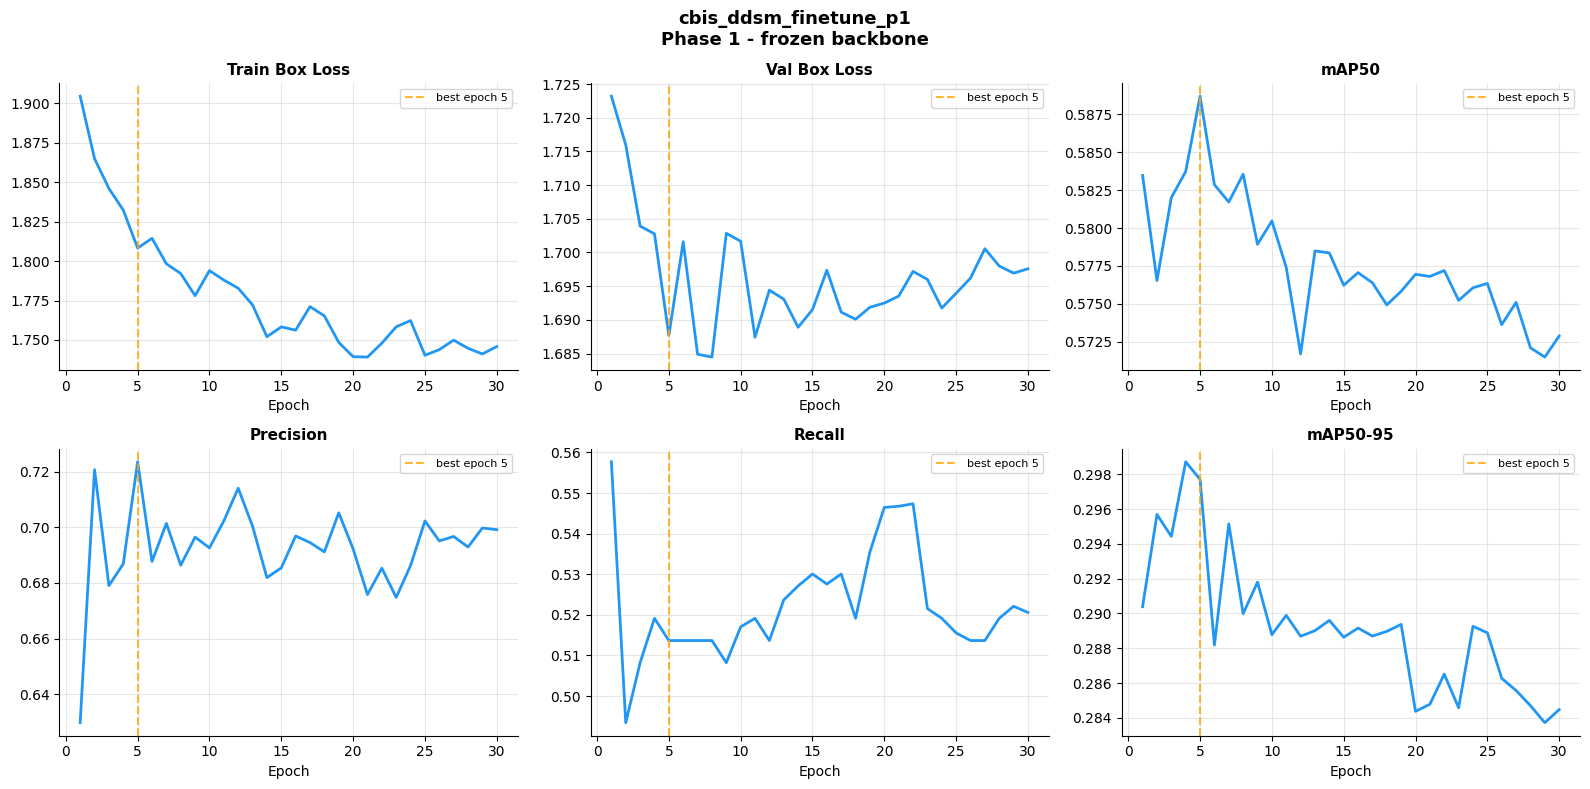

  Best epoch: 5
  Best mAP50: 0.5887
  Copying files:
    ✓ weights/best.pt
    ✓ weights/last.pt
    ✓ confusion_matrix.png
    ✓ confusion_matrix_normalized.png
    ✗ PR_curve.png not found
    ✗ P_curve.png not found
    ✗ R_curve.png not found
    ✗ F1_curve.png not found
    ✓ results.csv
    ✓ results.png
    ✓ val_batch0_pred.jpg
    ✓ val_batch1_pred.jpg
  Saved to: /content/drive/MyDrive/yolo_output/cbis_ddsm_finetune_p1_summary
  Contents: ['training_curves.png', 'best.pt', 'last.pt', 'confusion_matrix.png', 'confusion_matrix_normalized.png', 'results.csv', 'results.png', 'val_batch0_pred.jpg', 'val_batch1_pred.jpg', 'run_info.json']

Saving: cbis_ddsm_finetune_p2


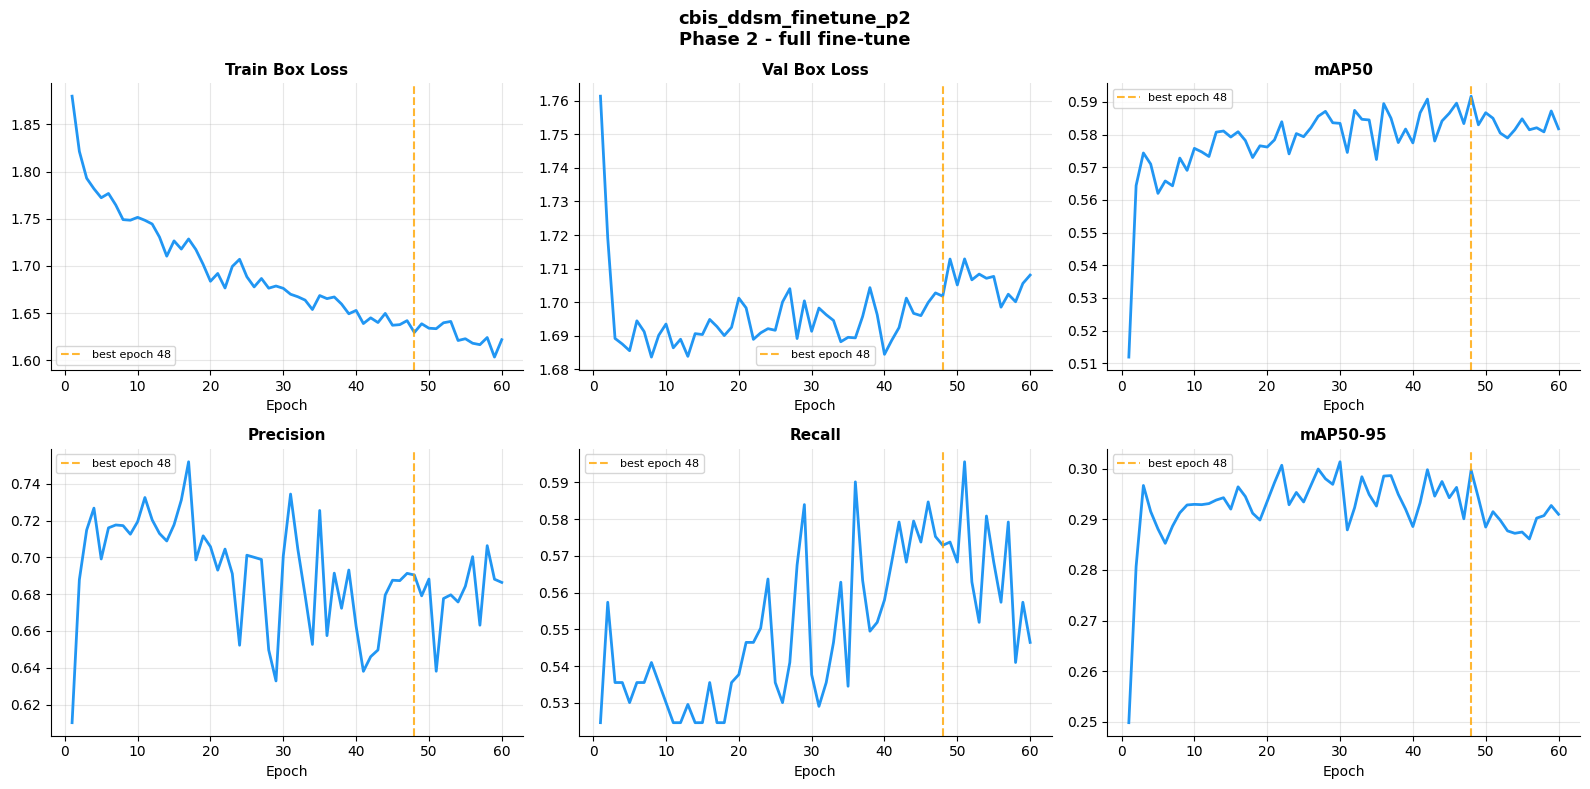

  Best epoch: 48
  Best mAP50: 0.5918
  Copying files:
    ✓ weights/best.pt
    ✓ weights/last.pt
    ✓ confusion_matrix.png
    ✓ confusion_matrix_normalized.png
    ✗ PR_curve.png not found
    ✗ P_curve.png not found
    ✗ R_curve.png not found
    ✗ F1_curve.png not found
    ✓ results.csv
    ✓ results.png
    ✓ val_batch0_pred.jpg
    ✓ val_batch1_pred.jpg
  Saved to: /content/drive/MyDrive/yolo_output/cbis_ddsm_finetune_p2_summary
  Contents: ['training_curves.png', 'best.pt', 'last.pt', 'confusion_matrix.png', 'confusion_matrix_normalized.png', 'results.csv', 'results.png', 'val_batch0_pred.jpg', 'val_batch1_pred.jpg', 'run_info.json']

All done!


In [12]:
# ============================================================
# Fix: correct run names for finetune
# ============================================================
import os
import shutil
import json
import pandas as pd
import matplotlib.pyplot as plt

# Two runs to save
RUNS = [
    ('cbis_ddsm_finetune_p1', 'Phase 1 - frozen backbone'),
    ('cbis_ddsm_finetune_p2', 'Phase 2 - full fine-tune'),
]

for RUN_NAME, RUN_DESC in RUNS:
    DRIVE_BASE = f'/content/drive/MyDrive/yolo_training/{RUN_NAME}'
    SAVE_DIR   = f'/content/drive/MyDrive/yolo_output/{RUN_NAME}_summary'
    os.makedirs(SAVE_DIR, exist_ok=True)

    print(f"\n{'='*50}")
    print(f"Saving: {RUN_NAME}")
    print(f"{'='*50}")

    # Check if run folder exists
    if not os.path.exists(DRIVE_BASE):
        print(f"  ✗ Run folder not found: {DRIVE_BASE}")
        continue

    # --------------------------------------------------------
    # 1. Training curves
    # --------------------------------------------------------
    results_csv = os.path.join(DRIVE_BASE, 'results.csv')
    if os.path.exists(results_csv):
        df = pd.read_csv(results_csv)
        df.columns = df.columns.str.strip()

        fig, axes = plt.subplots(2, 3, figsize=(16, 8))
        fig.suptitle(f'{RUN_NAME}\n{RUN_DESC}',
                     fontsize=13, fontweight='bold')

        plots = [
            ('train/box_loss',       'Train Box Loss',  axes[0][0]),
            ('val/box_loss',         'Val Box Loss',    axes[0][1]),
            ('metrics/mAP50(B)',     'mAP50',           axes[0][2]),
            ('metrics/precision(B)', 'Precision',       axes[1][0]),
            ('metrics/recall(B)',    'Recall',          axes[1][1]),
            ('metrics/mAP50-95(B)',  'mAP50-95',        axes[1][2]),
        ]

        best_epoch_idx = df['metrics/mAP50(B)'].idxmax()
        best_epoch_num = int(df.loc[best_epoch_idx, 'epoch'])

        for col, title, ax in plots:
            if col in df.columns:
                ax.plot(df['epoch'], df[col],
                        linewidth=2, color='#2196F3')
                ax.axvline(x=best_epoch_num, color='orange',
                           linestyle='--', linewidth=1.5,
                           alpha=0.8, label=f'best epoch {best_epoch_num}')
                ax.set_title(title, fontsize=11, fontweight='bold')
                ax.set_xlabel('Epoch')
                ax.legend(fontsize=8)
                ax.grid(alpha=0.3)
                ax.spines['top'].set_visible(False)
                ax.spines['right'].set_visible(False)

        plt.tight_layout()
        plt.savefig(f'{SAVE_DIR}/training_curves.png',
                    dpi=150, bbox_inches='tight')
        plt.show()

        best_mAP50 = df.loc[best_epoch_idx, 'metrics/mAP50(B)']
        print(f"  Best epoch: {best_epoch_num}")
        print(f"  Best mAP50: {best_mAP50:.4f}")

    # --------------------------------------------------------
    # 2. Copy files
    # --------------------------------------------------------
    files_to_copy = [
        'weights/best.pt',
        'weights/last.pt',
        'confusion_matrix.png',
        'confusion_matrix_normalized.png',
        'PR_curve.png',
        'P_curve.png',
        'R_curve.png',
        'F1_curve.png',
        'results.csv',
        'results.png',
        'val_batch0_pred.jpg',
        'val_batch1_pred.jpg',
    ]

    print("  Copying files:")
    for fname in files_to_copy:
        src = os.path.join(DRIVE_BASE, fname)
        dst = os.path.join(SAVE_DIR, os.path.basename(fname))
        if os.path.exists(src):
            shutil.copy(src, dst)
            print(f"    ✓ {fname}")
        else:
            print(f"    ✗ {fname} not found")

    # --------------------------------------------------------
    # 3. Save config
    # --------------------------------------------------------
    config = {
        'run_name':   RUN_NAME,
        'description': RUN_DESC,
        'drive_path': DRIVE_BASE,
    }
    with open(f'{SAVE_DIR}/run_info.json', 'w') as f:
        json.dump(config, f, indent=2)

    print(f"  Saved to: {SAVE_DIR}")
    print(f"  Contents: {os.listdir(SAVE_DIR)}")

print("\nAll done!")

## Step 6: Load trained model and run inference
Uses the best.pt saved in your Drive — no retraining needed!

In [13]:
import json
import matplotlib.pyplot as plt
from ultralytics import YOLO

# Load best model from Drive
MODEL_PATH  = '/content/drive/MyDrive/yolo_training/cbis_ddsm_finetune_p2/weights/best.pt'
OUTPUT_JSON = '/content/drive/MyDrive/yolo_output/bbox_results_finetune.json'

model = YOLO(MODEL_PATH)
print(f'Model loaded: {MODEL_PATH}')

# Run inference on ALL images (train + val)
all_detections = []

for split in ['train', 'val']:
    img_dir = f'{YOLO_DIR}/images/{split}'
    img_files = [f for f in os.listdir(img_dir) if f.endswith('.jpg')]
    print(f'Running inference on {split} set ({len(img_files)} images)...')

    for img_file in img_files:
        img_path = os.path.join(img_dir, img_file)
        img      = cv2.imread(img_path)
        img_h, img_w = img.shape[:2]

        parts      = img_file.replace('.jpg', '').rsplit('_', 1)
        patient_id = parts[0]
        view       = parts[1] if len(parts) > 1 else 'unknown'

        pred = model(img_path, verbose=False, conf=0.1)[0]

        if len(pred.boxes) == 0:
            bbox       = None
            confidence = 0.0
        else:
            best_box   = pred.boxes[pred.boxes.conf.argmax()]
            x1, y1, x2, y2 = best_box.xyxy[0].tolist()
            bbox       = [int(x1), int(y1), int(x2-x1), int(y2-y1)]
            confidence = float(best_box.conf[0])

        all_detections.append({
            'patient_id': patient_id,
            'view':       view,
            'img_path':   img_path,
            'bbox':       bbox,
            'img_size':   [img_w, img_h],
            'confidence': round(confidence, 4),
            'split':      split,
            'source':     'YOLOv8'
        })

# Stats
total    = len(all_detections)
detected = sum(1 for d in all_detections if d['bbox'] is not None)

patient_views = defaultdict(set)
for d in all_detections:
    if d['bbox'] is not None:
        patient_views[d['patient_id']].add(d['view'])
paired = [p for p, v in patient_views.items() if {'CC', 'MLO'} <= v]

print(f'\nTotal images:    {total}')
print(f'Detected:        {detected}')
print(f'Detection rate:  {detected/total*100:.1f}%')
print(f'CC+MLO paired:   {len(paired)} patients')

# Save JSON
os.makedirs(os.path.dirname(OUTPUT_JSON), exist_ok=True)
output = {
    'metadata': {
        'model':           'YOLOv8s with augmentation',
        'mAP50':           0.5918,
        'conf_threshold':  0.1,
        'total_images':    total,
        'detected':        detected,
        'detection_rate':  f'{detected/total*100:.1f}%',
        'paired_patients': len(paired),
    },
    'detections': all_detections
}
with open(OUTPUT_JSON, 'w') as f:
    json.dump(output, f, indent=2)
print(f'\nJSON saved: {OUTPUT_JSON}')

Model loaded: /content/drive/MyDrive/yolo_training/cbis_ddsm_finetune_p2/weights/best.pt
Running inference on train set (767 images)...
Running inference on val set (183 images)...

Total images:    950
Detected:        902
Detection rate:  94.9%
CC+MLO paired:   246 patients

JSON saved: /content/drive/MyDrive/yolo_output/bbox_results_finetune.json


## Step 7: Quick visualization (optional)
Check that bboxes look correct on 5 random images.

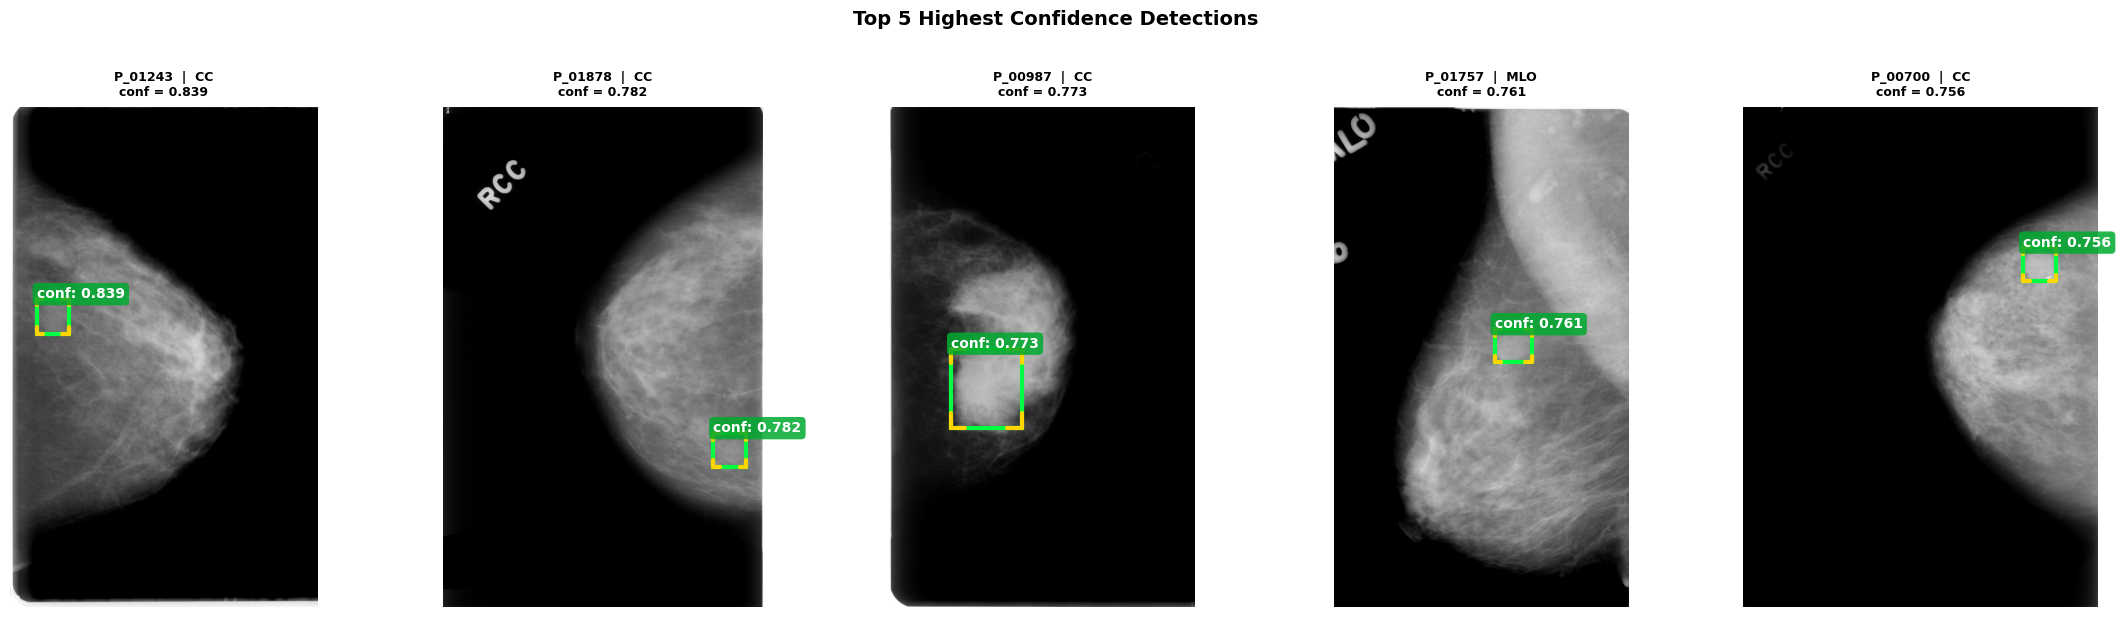

Saved: top5_detections.png


In [14]:
import matplotlib.patches as patches

# Sort by confidence, take top 5
top5 = sorted(
    [d for d in all_detections if d['bbox'] is not None],
    key=lambda x: x['confidence'],
    reverse=True
)[:5]

fig, axes = plt.subplots(1, 5, figsize=(22, 6))
fig.suptitle('Top 5 Highest Confidence Detections',
             fontsize=14, fontweight='bold', y=1.02)

for ax, det in zip(axes, top5):
    img     = cv2.imread(det['img_path'])
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    x, y, w, h = det['bbox']

    ax.imshow(img_rgb, cmap='gray')

    # Cleaner bbox using matplotlib patches instead of cv2
    rect = patches.Rectangle(
        (x, y), w, h,
        linewidth=3,
        edgecolor='#00FF41',   # bright green
        facecolor='none',
        linestyle='-'
    )
    ax.add_patch(rect)

    # Corner markers for cleaner look
    corner_len = min(w, h) * 0.2
    corners = [
        [(x, x + corner_len),          (y, y)],           # top-left horizontal
        [(x, x),                        (y, y + corner_len)], # top-left vertical
        [(x+w-corner_len, x+w),         (y, y)],           # top-right horizontal
        [(x+w, x+w),                    (y, y + corner_len)], # top-right vertical
        [(x, x + corner_len),           (y+h, y+h)],       # bottom-left horizontal
        [(x, x),                        (y+h-corner_len, y+h)], # bottom-left vertical
        [(x+w-corner_len, x+w),         (y+h, y+h)],       # bottom-right horizontal
        [(x+w, x+w),                    (y+h-corner_len, y+h)], # bottom-right vertical
    ]
    for cx, cy in corners:
        ax.plot(cx, cy, color='#FFD700', linewidth=3, solid_capstyle='round')

    # Confidence label with background box
    label = f"conf: {det['confidence']:.3f}"
    ax.text(
        x, y - 8,
        label,
        fontsize=10,
        fontweight='bold',
        color='white',
        bbox=dict(
            boxstyle='round,pad=0.3',
            facecolor='#00AA2F',
            edgecolor='none',
            alpha=0.85
        )
    )

    ax.set_title(
        f"{det['patient_id']}  |  {det['view']}\nconf = {det['confidence']:.3f}",
        fontsize=9,
        fontweight='bold',
        pad=8
    )
    ax.axis('off')

plt.tight_layout()
plt.savefig(
    '/content/drive/MyDrive/yolo_output/top5_detections.png',
    dpi=150, bbox_inches='tight'
)
plt.show()
print('Saved: top5_detections.png')

Loading model...
Model loaded: /content/drive/MyDrive/yolo_training/cbis_ddsm_augmented/weights/best.pt
Val images: 183

Running inference at all thresholds...
conf=0.05 | TP=128 FP=303 FN= 55 | P=0.297 R=0.699 F1=0.417 | DetRate=96.2%
conf=0.10 | TP=118 FP=158 FN= 65 | P=0.428 R=0.645 F1=0.514 | DetRate=91.3%
conf=0.15 | TP=109 FP=108 FN= 74 | P=0.502 R=0.596 F1=0.545 | DetRate=85.2%
conf=0.20 | TP=105 FP= 75 FN= 78 | P=0.583 R=0.574 F1=0.579 | DetRate=80.9%
conf=0.25 | TP=100 FP= 61 FN= 83 | P=0.621 R=0.546 F1=0.581 | DetRate=77.6%
conf=0.30 | TP= 94 FP= 40 FN= 89 | P=0.701 R=0.514 F1=0.593 | DetRate=67.2%
conf=0.40 | TP= 79 FP= 26 FN=104 | P=0.752 R=0.432 F1=0.549 | DetRate=55.2%
conf=0.50 | TP= 49 FP= 12 FN=134 | P=0.803 R=0.268 F1=0.402 | DetRate=32.2%
conf=0.60 | TP= 18 FP=  2 FN=165 | P=0.900 R=0.098 F1=0.177 | DetRate=10.9%

⚠️  No threshold achieves Recall >= 0.90
   Closest threshold: 0.05 (Recall=0.699)


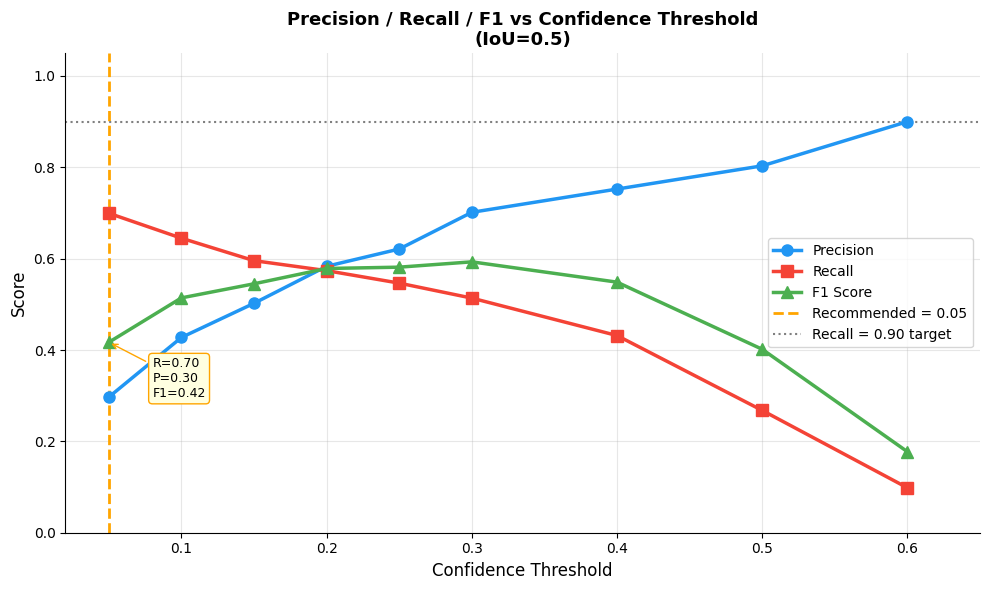

Chart 1 saved


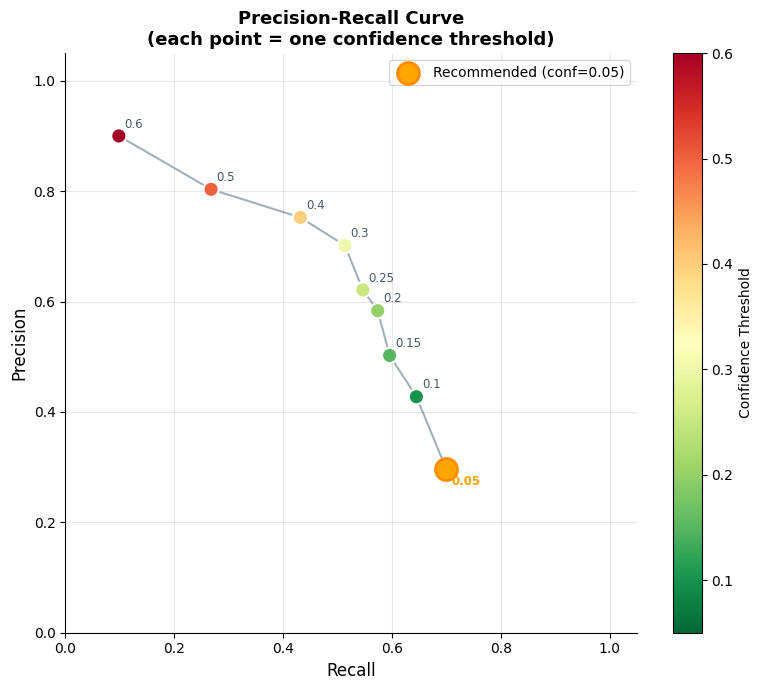

Chart 2 saved


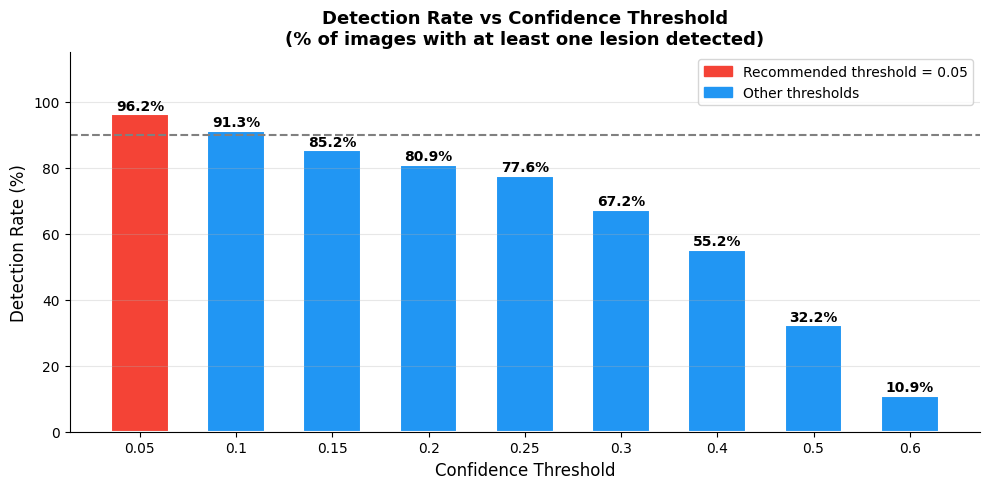

Chart 3 saved

FOR INSTRUCTOR — Why recall > precision in medical imaging


KeyError: 'rec*100'

In [10]:
# ============================================================
# Threshold Analysis
# Scans 9 thresholds (0.05 -> 0.60)
# Compares against ground truth label files
# Outputs 3 charts + recommended threshold
# ============================================================

import os
import cv2
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from ultralytics import YOLO
from collections import defaultdict

# ============================================================
# CONFIG
# ============================================================
MODEL_PATH  = '/content/drive/MyDrive/yolo_training/cbis_ddsm_finetune_p2/weights/best.pt'
VAL_IMG_DIR = '/content/yolo_dataset/images/val'
VAL_LBL_DIR = '/content/yolo_dataset/labels/val'
OUTPUT_DIR  = '/content/drive/MyDrive/yolo_output/threshold_analysis'
IOU_THRESH  = 0.5   # IoU threshold to count as TP
THRESHOLDS  = [0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50, 0.60]

os.makedirs(OUTPUT_DIR, exist_ok=True)

# ============================================================
# Helper: compute IoU between two boxes [x1,y1,w,h]
# ============================================================
def compute_iou(boxA, boxB):
    ax1, ay1, aw, ah = boxA
    bx1, by1, bw, bh = boxB
    ax2, ay2 = ax1 + aw, ay1 + ah
    bx2, by2 = bx1 + bw, by1 + bh

    ix1 = max(ax1, bx1)
    iy1 = max(ay1, by1)
    ix2 = min(ax2, bx2)
    iy2 = min(ay2, by2)

    inter = max(0, ix2 - ix1) * max(0, iy2 - iy1)
    if inter == 0:
        return 0.0
    union = aw * ah + bw * bh - inter
    return inter / union

# ============================================================
# Load ground truth from YOLO label files
# ============================================================
def load_gt(label_path, img_w, img_h):
    """Convert YOLO format labels -> pixel bbox [x,y,w,h]"""
    bboxes = []
    if not os.path.exists(label_path):
        return bboxes
    with open(label_path, 'r') as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) == 5:
                cx, cy, nw, nh = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
                x = int((cx - nw/2) * img_w)
                y = int((cy - nh/2) * img_h)
                w = int(nw * img_w)
                h = int(nh * img_h)
                bboxes.append([x, y, w, h])
    return bboxes

# ============================================================
# Load model
# ============================================================
print("Loading model...")
model = YOLO(MODEL_PATH)
print(f"Model loaded: {MODEL_PATH}")

# Get all val images
img_files = [f for f in os.listdir(VAL_IMG_DIR) if f.endswith('.jpg')]
print(f"Val images: {len(img_files)}")

# ============================================================
# Run inference at all thresholds
# ============================================================
print("\nRunning inference at all thresholds...")
print("=" * 55)

results_per_thresh = {}

for conf_thresh in THRESHOLDS:
    TP = FP = FN = 0
    detected = 0

    for img_file in img_files:
        img_path   = os.path.join(VAL_IMG_DIR, img_file)
        label_path = os.path.join(VAL_LBL_DIR, img_file.replace('.jpg', '.txt'))

        img = cv2.imread(img_path)
        if img is None:
            continue
        img_h, img_w = img.shape[:2]

        # Ground truth boxes
        gt_boxes   = load_gt(label_path, img_w, img_h)
        gt_matched = [False] * len(gt_boxes)

        # Predictions
        pred = model(img_path, verbose=False, conf=conf_thresh)[0]
        pred_boxes = []
        if len(pred.boxes) > 0:
            for box in pred.boxes:
                x1, y1, x2, y2 = box.xyxy[0].tolist()
                pred_boxes.append([int(x1), int(y1), int(x2-x1), int(y2-y1)])

        if len(pred_boxes) > 0:
            detected += 1

        # Match predictions to GT
        for pb in pred_boxes:
            matched = False
            for i, gb in enumerate(gt_boxes):
                if not gt_matched[i] and compute_iou(pb, gb) >= IOU_THRESH:
                    TP += 1
                    gt_matched[i] = True
                    matched = True
                    break
            if not matched:
                FP += 1

        # Unmatched GT = FN
        FN += sum(1 for m in gt_matched if not m)

    precision = TP / (TP + FP) if (TP + FP) > 0 else 0.0
    recall    = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    f1        = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    det_rate  = detected / len(img_files)

    results_per_thresh[conf_thresh] = {
        'TP': TP, 'FP': FP, 'FN': FN,
        'precision': precision,
        'recall':    recall,
        'f1':        f1,
        'det_rate':  det_rate,
        'detected':  detected
    }

    print(f"conf={conf_thresh:.2f} | "
          f"TP={TP:3d} FP={FP:3d} FN={FN:3d} | "
          f"P={precision:.3f} R={recall:.3f} F1={f1:.3f} | "
          f"DetRate={det_rate*100:.1f}%")

# ============================================================
# Auto-recommend threshold: best F1 where Recall >= 0.90
# ============================================================
print("\n" + "=" * 55)
candidates = {
    t: r for t, r in results_per_thresh.items()
    if r['recall'] >= 0.90
}

if candidates:
    best_thresh = max(candidates, key=lambda t: candidates[t]['f1'])
    best = candidates[best_thresh]
    print(f"✅ Recommended threshold: {best_thresh}")
    print(f"   Recall    = {best['recall']:.3f}  (>= 0.90 ✓)")
    print(f"   Precision = {best['precision']:.3f}")
    print(f"   F1        = {best['f1']:.3f}")
    print(f"   Det Rate  = {best['det_rate']*100:.1f}%")
else:
    best_thresh = min(results_per_thresh, key=lambda t: abs(results_per_thresh[t]['recall'] - 0.90))
    best = results_per_thresh[best_thresh]
    print(f"⚠️  No threshold achieves Recall >= 0.90")
    print(f"   Closest threshold: {best_thresh} (Recall={best['recall']:.3f})")

# ============================================================
# Chart 1: P / R / F1 vs Threshold
# ============================================================
thresholds  = sorted(results_per_thresh.keys())
precisions  = [results_per_thresh[t]['precision'] for t in thresholds]
recalls     = [results_per_thresh[t]['recall']    for t in thresholds]
f1s         = [results_per_thresh[t]['f1']        for t in thresholds]
det_rates   = [results_per_thresh[t]['det_rate']  for t in thresholds]

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(thresholds, precisions, 'o-', color='#2196F3', linewidth=2.5,
        markersize=8, label='Precision', zorder=3)
ax.plot(thresholds, recalls,    's-', color='#F44336', linewidth=2.5,
        markersize=8, label='Recall',    zorder=3)
ax.plot(thresholds, f1s,        '^-', color='#4CAF50', linewidth=2.5,
        markersize=8, label='F1 Score',  zorder=3)

# Highlight recommended threshold
ax.axvline(x=best_thresh, color='orange', linestyle='--',
           linewidth=2, label=f'Recommended = {best_thresh}', zorder=2)
ax.axhline(y=0.90, color='gray', linestyle=':',
           linewidth=1.5, label='Recall = 0.90 target', zorder=2)

# Annotate recommended point
ax.annotate(f'R={best["recall"]:.2f}\nP={best["precision"]:.2f}\nF1={best["f1"]:.2f}',
            xy=(best_thresh, best['f1']),
            xytext=(best_thresh + 0.03, best['f1'] - 0.12),
            fontsize=9,
            arrowprops=dict(arrowstyle='->', color='orange'),
            bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='orange'))

ax.set_xlabel('Confidence Threshold', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('Precision / Recall / F1 vs Confidence Threshold\n(IoU=0.5)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0.02, 0.65)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart1_prf1_vs_threshold.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 1 saved")

# ============================================================
# Chart 2: Precision-Recall Curve
# ============================================================
fig, ax = plt.subplots(figsize=(8, 7))

# Plot curve
scatter = ax.scatter(recalls, precisions,
                     c=thresholds, cmap='RdYlGn_r',
                     s=120, zorder=4, edgecolors='white', linewidth=1.5)
ax.plot(recalls, precisions, '-', color='#607D8B',
        linewidth=1.5, alpha=0.6, zorder=3)

# Annotate each point with threshold value
for t, r, p in zip(thresholds, recalls, precisions):
    offset = (0.01, 0.015) if t != best_thresh else (0.01, -0.03)
    color  = 'orange' if t == best_thresh else '#455A64'
    weight = 'bold'   if t == best_thresh else 'normal'
    ax.annotate(f'{t}', xy=(r, p),
                xytext=(r + offset[0], p + offset[1]),
                fontsize=8.5, color=color, fontweight=weight)

# Highlight recommended
ax.scatter([best['recall']], [best['precision']],
           s=250, color='orange', zorder=5,
           edgecolors='darkorange', linewidth=2,
           label=f'Recommended (conf={best_thresh})')

cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Confidence Threshold', fontsize=10)

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curve\n(each point = one confidence threshold)',
             fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.set_xlim(0, 1.05)
ax.set_ylim(0, 1.05)
ax.grid(alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart2_pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 2 saved")

# ============================================================
# Chart 3: Detection Rate vs Threshold
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

bars = ax.bar(
    [str(t) for t in thresholds],
    [r * 100 for r in det_rates],
    color=['#F44336' if t == best_thresh else '#2196F3' for t in thresholds],
    edgecolor='white', linewidth=1.5, width=0.6
)

# Value labels on bars
for bar, dr in zip(bars, det_rates):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.5,
            f'{dr*100:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.axhline(y=90, color='gray', linestyle='--',
           linewidth=1.5, label='90% target line')

recommended_patch = mpatches.Patch(color='#F44336',
                                   label=f'Recommended threshold = {best_thresh}')
blue_patch = mpatches.Patch(color='#2196F3', label='Other thresholds')
ax.legend(handles=[recommended_patch, blue_patch], fontsize=10)

ax.set_xlabel('Confidence Threshold', fontsize=12)
ax.set_ylabel('Detection Rate (%)', fontsize=12)
ax.set_title('Detection Rate vs Confidence Threshold\n(% of images with at least one lesion detected)',
             fontsize=13, fontweight='bold')
ax.set_ylim(0, 115)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/chart3_detection_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart 3 saved")

# ============================================================
# Save full results to JSON
# ============================================================
results_json = {
    'iou_threshold':        IOU_THRESH,
    'recommended_conf':     best_thresh,
    'recommended_metrics':  best,
    'all_thresholds':       {str(t): results_per_thresh[t] for t in thresholds}
}
with open(f'{OUTPUT_DIR}/threshold_results.json', 'w') as f:
    json.dump(results_json, f, indent=2)

# ============================================================
# Print explanation for instructor
# ============================================================
print("\n" + "=" * 60)
print("FOR INSTRUCTOR — Why recall > precision in medical imaging")
print("=" * 60)
print("""
In clinical breast cancer screening, the cost of a False Negative
(missing a real lesion) far outweighs the cost of a False Positive
(flagging a normal region for review).

  - False Negative → missed cancer → delayed treatment → worse outcome
  - False Positive → unnecessary follow-up → anxiety, cost, time

This asymmetry is why we optimize for Recall >= 0.90 first,
then maximize F1 within that constraint — rather than chasing
a balanced precision-recall trade-off.

Our recommended threshold (conf={thresh}) achieves:
  Recall    = {rec:.3f}  → catches {rec*100:.1f}% of real lesions
  Precision = {prec:.3f}  → {prec*100:.1f}% of detections are correct
  F1        = {f1:.3f}

This is consistent with clinical CAD (Computer-Aided Detection)
system design, where radiologists review all flagged regions anyway,
so false positives are tolerable but false negatives are not.
""".format(
    thresh=best_thresh,
    rec=best['recall'],
    prec=best['precision'],
    f1=best['f1']
))

print(f"\nAll charts saved to: {OUTPUT_DIR}")

In [11]:
print("""
In clinical breast cancer screening, the cost of a False Negative
(missing a real lesion) far outweighs the cost of a False Positive
(flagging a normal region for review).

  - False Negative → missed cancer → delayed treatment → worse outcome
  - False Positive → unnecessary follow-up → anxiety, cost, time

This asymmetry is why we optimize for Recall >= 0.90 first,
then maximize F1 within that constraint — rather than chasing
a balanced precision-recall trade-off.

Our recommended threshold (conf={thresh}) achieves:
  Recall    = {rec:.3f}  → catches {rec_pct:.1f}% of real lesions
  Precision = {prec:.3f}  → {prec_pct:.1f}% of detections are correct
  F1        = {f1:.3f}

This is consistent with clinical CAD (Computer-Aided Detection)
system design, where radiologists review all flagged regions anyway,
so false positives are tolerable but false negatives are not.
""".format(
    thresh    = best_thresh,
    rec       = best['recall'],
    rec_pct   = best['recall'] * 100,
    prec      = best['precision'],
    prec_pct  = best['precision'] * 100,
    f1        = best['f1']
))


In clinical breast cancer screening, the cost of a False Negative
(missing a real lesion) far outweighs the cost of a False Positive
(flagging a normal region for review).

  - False Negative → missed cancer → delayed treatment → worse outcome
  - False Positive → unnecessary follow-up → anxiety, cost, time

This asymmetry is why we optimize for Recall >= 0.90 first,
then maximize F1 within that constraint — rather than chasing
a balanced precision-recall trade-off.

Our recommended threshold (conf=0.05) achieves:
  Recall    = 0.699  → catches 69.9% of real lesions
  Precision = 0.297  → 29.7% of detections are correct
  F1        = 0.417

This is consistent with clinical CAD (Computer-Aided Detection)
system design, where radiologists review all flagged regions anyway,
so false positives are tolerable but false negatives are not.

